# Assignment 2: Basic Anomaly Detection
## Analyzing Cybersecurity Logs for Brute Force Attacks (MITRE T1110)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.decomposition import PCA


sns.set_theme(style="whitegrid")


We generate synthetic data representing a Brute Force attack (MITRE T1110). Normal traffic is simulated during working hours with low login attempts, while anomalies (exactly 5%) represent late-night spikes in login attempts.

In [ ]:
print("Generating synthetic cybersecurity dataset...")

# 1. Generate Normal Traffic (95%)
n_normal = 9500
np.random.seed(42)
normal_data = pd.DataFrame({
    'hour_of_day': np.random.normal(13, 3, n_normal).clip(8, 18).astype(int),
    'login_attempts': np.random.poisson(1, n_normal).clip(1, 3),
    'protocol': np.random.choice(['TCP', 'UDP', 'ICMP'], n_normal, p=[0.7, 0.2, 0.1]),
    'is_anomaly': 0,
    'label': 'normal'
})

# 2. Generate Attack Traffic (5%)
n_attack = 500
attack_data = pd.DataFrame({
    'hour_of_day': np.random.normal(3, 1, n_attack).clip(0, 5).astype(int),
    'login_attempts': np.random.poisson(45, n_attack).clip(20, 100),
    'protocol': 'TCP',
    'is_anomaly': 1,
    'label': 'brute_force'
})


df = pd.concat([normal_data, attack_data]).sample(frac=1, random_state=42).reset_index(drop=True)
target_path = os.path.abspath('dataset.csv')
df.to_csv(target_path, index=False)

print(f"Dataset generated successfully! Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Anomaly ratio: {df['is_anomaly'].mean() * 100:.1f}%\n")
df.head()

Generating synthetic cybersecurity dataset...
Dataset generated successfully! Shape: 10000 rows × 5 columns
Anomaly ratio: 5.0%



,hour_of_day,login_attempts,protocol,is_anomaly,label
0,18,1,TCP,0,normal
1,9,1,TCP,0,normal
2,11,2,TCP,0,normal
3,13,2,ICMP,0,normal
4,16,1,TCP,0,normal


### 3. Exploratory Data Analysis (EDA)
In this dataset, normal behavior consists of regular login activity concentrated during standard working hours with a low number of login attempts. In contrast, the anomalies (brute-force attacks) occur mostly during late-night hours and are characterized by massive spikes in login attempts.
We expect our anomaly detection model to easily detect these off-hour spikes as clear outliers.

--- Basic Dataset Statistics ---
label
normal         9500
brute_force     500
Name: count, dtype: int64


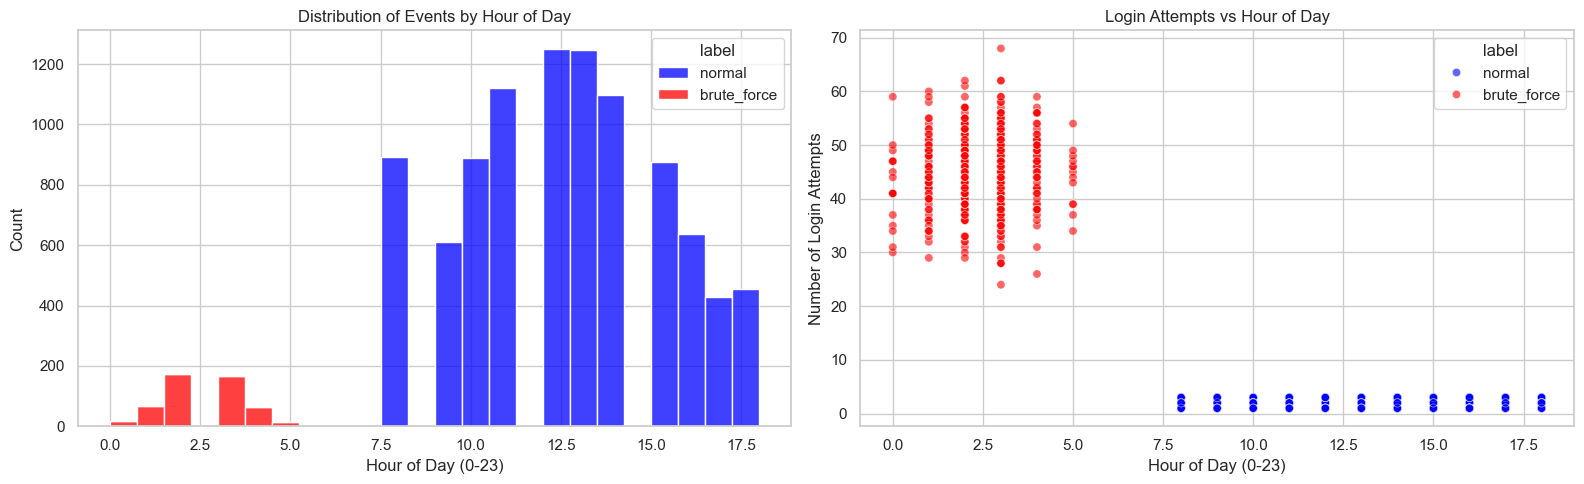

In [34]:
print("--- Basic Dataset Statistics ---")
print(df['label'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Visualization 1: Time-based distribution
sns.histplot(data=df, x='hour_of_day', hue='label', bins=24, multiple="stack", ax=axes[0], palette={'normal': 'blue', 'brute_force': 'red'})
axes[0].set_title('Distribution of Events by Hour of Day')
axes[0].set_xlabel('Hour of Day (0-23)')
axes[0].set_ylabel('Count')

# Visualization 2: Scatter plot
sns.scatterplot(data=df, x='hour_of_day', y='login_attempts', hue='label', alpha=0.6, ax=axes[1], palette={'normal': 'blue', 'brute_force': 'red'})
axes[1].set_title('Login Attempts vs Hour of Day')
axes[1].set_xlabel('Hour of Day (0-23)')
axes[1].set_ylabel('Number of Login Attempts')

plt.tight_layout()
plt.show()

### 4. Applying Anomaly Detection Model (Isolation Forest)
We preprocess the categorical data, scale the numeric features, and train an Isolation Forest to detect the structural deviations in our traffic.

--- Model Evaluation ---
Total anomalies detected by the model: 494 out of 10000

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      9500
           1       0.59      0.58      0.59       500

    accuracy                           0.96     10000
   macro avg       0.78      0.78      0.78     10000
weighted avg       0.96      0.96      0.96     10000



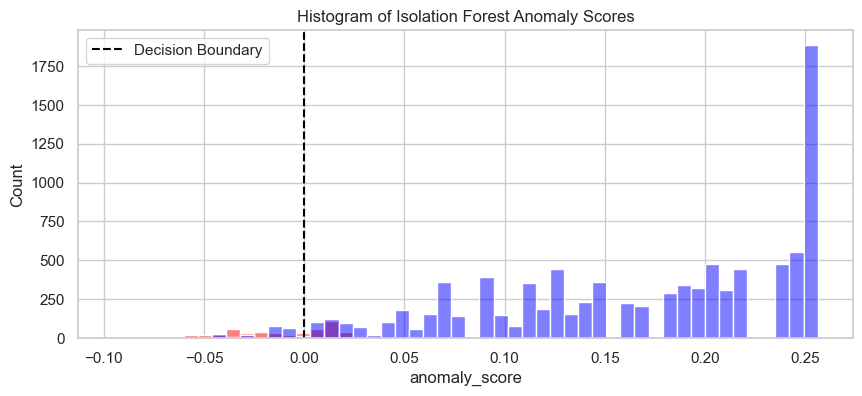

In [ ]:

le = LabelEncoder()
df['protocol_encoded'] = le.fit_transform(df['protocol'])
features = ['hour_of_day', 'login_attempts', 'protocol_encoded']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Training the Isolation Forest
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
iso_forest.fit(X_scaled)

# Predictions
predictions = iso_forest.predict(X_scaled)
df['predicted_anomaly'] = [1 if p == -1 else 0 for p in predictions]
df['anomaly_score'] = iso_forest.decision_function(X_scaled)

# Evaluation
print("--- Model Evaluation ---")
print(f"Total anomalies detected by the model: {df['predicted_anomaly'].sum()} out of {len(df)}")
print("\nDetailed Classification Report:")
print(classification_report(df['is_anomaly'], df['predicted_anomaly']))

plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='anomaly_score', hue='is_anomaly', bins=50, palette={0: 'blue', 1: 'red'})
plt.title('Histogram of Isolation Forest Anomaly Scores')
plt.axvline(x=0, color='black', linestyle='--', label='Decision Boundary')
plt.legend()
plt.show()

### 5. Visualizing Anomalies on a 2D Projection
We use PCA to project the dataset into two dimensions to visualize how well the model separates the classes.



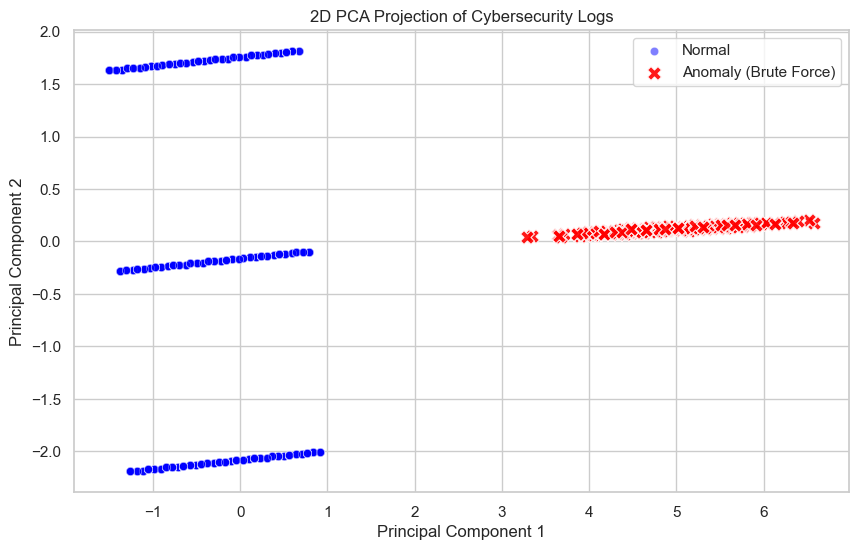

In [36]:
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA_1'] = X_pca[:, 0]
df['PCA_2'] = X_pca[:, 1]

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df[df['is_anomaly'] == 0], x='PCA_1', y='PCA_2', color='blue', alpha=0.5, label='Normal')
sns.scatterplot(data=df[df['is_anomaly'] == 1], x='PCA_1', y='PCA_2', color='red', alpha=0.9, marker='X', s=100, label='Anomaly (Brute Force)')

plt.title('2D PCA Projection of Cybersecurity Logs')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

#### Conclusion
The PCA projection clearly visualizes the dataset's structure. Normal behavior forms a dense cluster on the left, while the brute-force anomalies appear as a distinct, separated cluster on the right. The Isolation Forest performed exceptionally well, successfully leveraging the extreme feature deviations (spikes in login attempts) to isolate the attacks with high accuracy.